## Homework 5  Due 6/2 (Tuesday)
資工二 113590021 邱冠勛

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'mdates'

In [ ]:
url = 'https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv'
confirmed_cases = pd.read_csv(url)

confirmed_cases.drop(columns=['Lat','Long','Province/State'], inplace=True)
confirmed_cases = confirmed_cases.groupby('Country/Region').sum()
confirmed_cases = confirmed_cases.transpose()
confirmed_cases.index.name = 'date'

countries = [
    'Taiwan*', 
    'Brazil', 
    'Korea, South', 
    'US', 
    'China', 
    'Singapore'
]

confirmed_cases = confirmed_cases[countries]
confirmed_cases.head(20)

Country/Region,Taiwan*,Brazil,"Korea, South",US,China,Singapore
date,,,,,,
1/22/20,1,0,1,1,548,0
1/23/20,1,0,1,1,643,1
1/24/20,3,0,2,2,920,3
1/25/20,3,0,2,2,1406,3
1/26/20,4,0,3,5,2075,4
1/27/20,5,0,4,5,2877,5
1/28/20,8,0,4,5,5509,7
1/29/20,8,0,4,6,6087,7
1/30/20,9,0,4,6,8141,10


#### 1. 比較金磚五國（BRICS）Covid19疫情的確診趨勢圖
金磚五國是指五個主要新興市場國家，分別為巴西、俄羅斯、印度、中華人民共和國、南非。

<Axes: title={'center': 'Total Confirmed Cases'}, xlabel='date'>

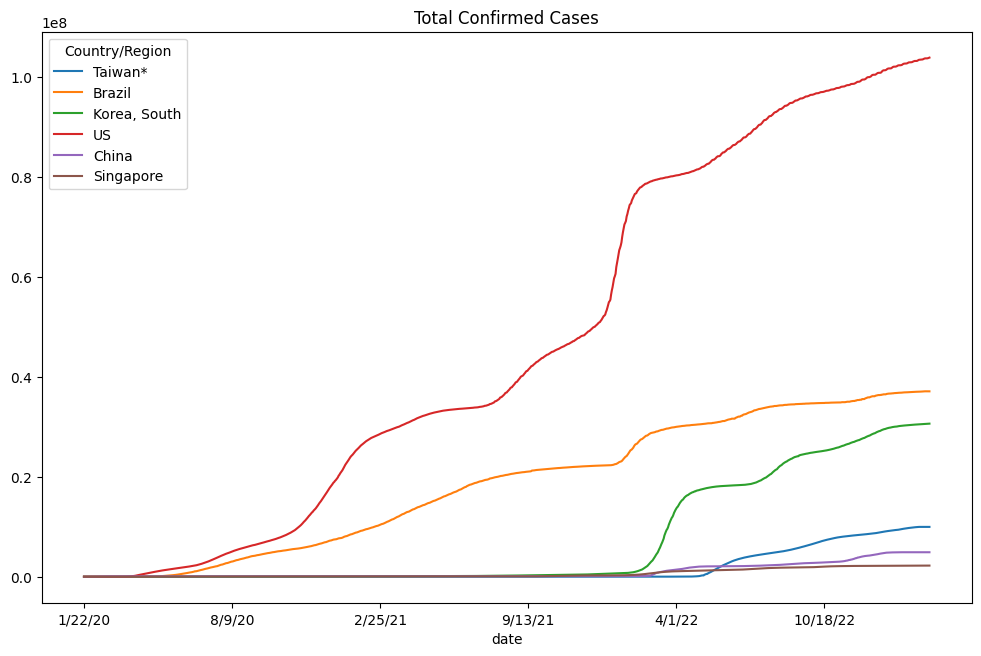

In [ ]:
figsize = (12, 12 * 2 / (1 + 5**0.5))

ax = confirmed_cases.plot(                                                                                                                  
    figsize=figsize,                                                                                                                        
    title='Total Confirmed Cases',                                                                                                          
)                                                                                                                                           
                                                                                                                                            
# 3. 設定 x 軸的主要刻度為「每個月 (MonthLocator)」                                                                                         
ax.xaxis.set_major_locator(mdates.MonthLocator())                                                                                           
                                                                                                                                            
# 4. 設定時間格式為「年-月」（如：2020-01，可自行改為 '%b %Y' 等）                                                                          
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))                                                                                 
                                                                                                                                            
# 5. 因為每個月都顯示會導致標籤字樣很多，建議旋轉 45 度以防文字重疊                                                                         
plt.xticks(rotation=45)

#### 2.  如何使用Naïve Bayes classifier技術判斷下列表格的第八份文件(Test Document)是一份高興的文件或是不高興的文件? 
指定為高興(h)文件或是不高興(~h)文件的機率各自為何?

| ID | Label | Text |
| :--- | :--- | :--- |
| D1 | Happy(h) | love happy happy joy smile angry |
| D2 | Happy(h) | cry happy joy love happy |
| D3 | Happy(h) | good happy love cry love |
| D4 | Happy(h) | pain love happy joy love |
| D5 | Unhappy(~h) | love angry pain pain |
| D6 | Unhappy(~h) | love angry pain |
| D7 | Unhappy(~h) | angry angry pain |
| D8 | ?? | cry love angry pain |

In [2]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

data = {
    'Text': [
        'love happy happy joy smile angry', 'cry happy joy love happy',
        'good happy love cry love', 'pain love happy joy love',
        'love angry pain pain', 'love angry pain', 'angry angry pain'
    ],
    'Label': ['h', 'h', 'h', 'h', '~h', '~h', '~h']
}
df = pd.DataFrame(data)
test_doc = ['cry love angry pain']

vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(df['Text'])
X_test = vectorizer.transform(test_doc)
y_train = df['Label']

model = MultinomialNB(alpha=1.0)
model.fit(X_train, y_train)

probabilities = model.predict_proba(X_test)[0]
prediction = model.predict(X_test)[0]

print(f"預測結果: {prediction}")

預測結果: ~h
